In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder


In [37]:
credit=pd.read_csv('c:/data/credit.csv')
credit.shape

(1000, 21)

In [38]:
credit.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,1,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,2,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,2,2,none,yes,skilled employee


In [39]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_length     1000 non-null   object
 7   installment_rate      1000 non-null   int64 
 8   personal_status       1000 non-null   object
 9   other_debtors         1000 non-null   object
 10  residence_history     1000 non-null   int64 
 11  property              1000 non-null   object
 12  age                   1000 non-null   int64 
 13  installment_plan      1000 non-null   object
 14  housing               1000 non-null   object
 15  existing_credits      1000 non-null   i

In [40]:
credit.isna().sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_length       0
installment_rate        0
personal_status         0
other_debtors           0
residence_history       0
property                0
age                     0
installment_plan        0
housing                 0
existing_credits        0
default                 0
dependents              0
telephone               0
foreign_worker          0
job                     0
dtype: int64

In [41]:
credit.default.value_counts()

default
1    700
2    300
Name: count, dtype: int64

In [42]:
credit.dependents.value_counts()

dependents
1    845
2    155
Name: count, dtype: int64

In [43]:
credit.default=credit.default.apply(lambda x:'Repaid' if x==1 else 'Delayed')
credit.default.value_counts()


default
Repaid     700
Delayed    300
Name: count, dtype: int64

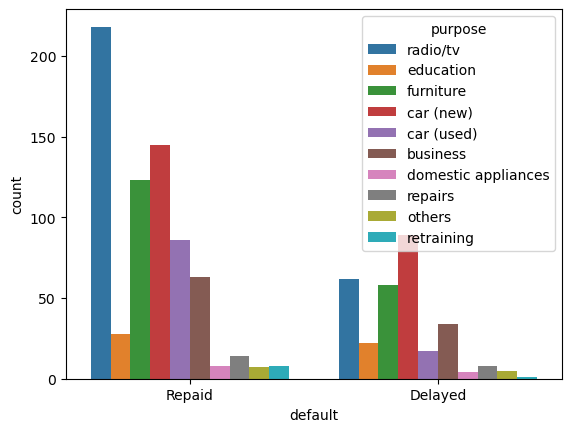

In [46]:
sns.countplot(x='default',data=credit,hue='purpose')
plt.show()

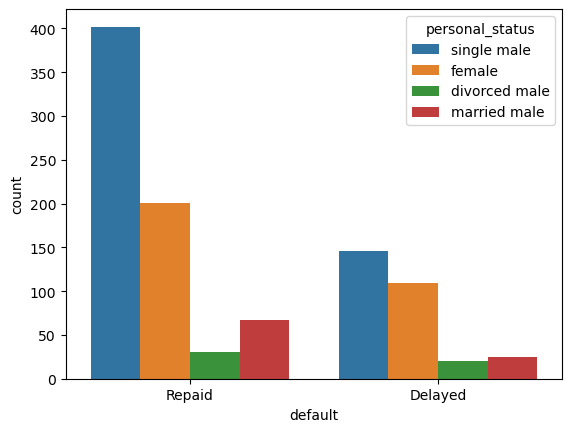

In [61]:
sns.countplot(x='default',data=credit,hue='personal_status')
plt.show()

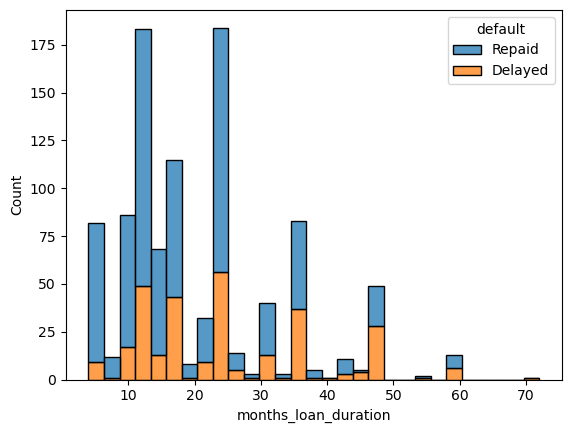

In [64]:
sns.histplot(x='months_loan_duration',data=credit,hue='default',multiple='stack')
plt.show()

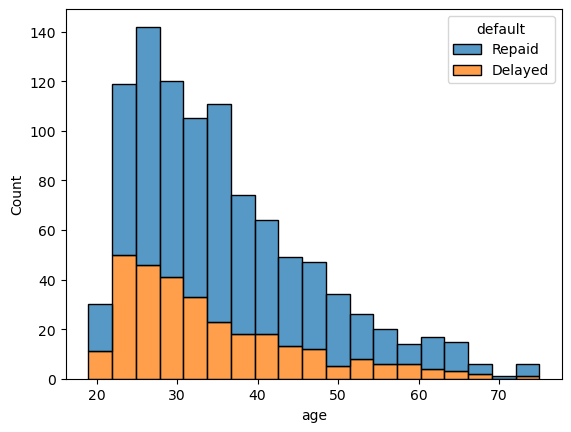

In [66]:
sns.histplot(x='age',data=credit,hue='default',multiple='stack')
plt.show()

In [142]:
X=credit[['amount','months_loan_duration','existing_credits','checking_balance','savings_balance']]
y=credit['default']

In [143]:
columns=['existing_credits','checking_balance','savings_balance']
encoding=LabelEncoder()
for c in columns:
    X[c]=encoding.fit_transform(X[c])



In [144]:
from warnings import filterwarnings

In [145]:
filterwarnings(action='ignore')

In [146]:
X.personal_status.value_counts()

AttributeError: 'DataFrame' object has no attribute 'personal_status'

In [147]:
y

0       Repaid
1      Delayed
2       Repaid
3       Repaid
4      Delayed
        ...   
995     Repaid
996     Repaid
997     Repaid
998    Delayed
999     Repaid
Name: default, Length: 1000, dtype: object

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [149]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=10,test_size=0.2)
X_train.shape,X_test.shape

((800, 5), (200, 5))

In [150]:
model=DecisionTreeClassifier(criterion='entropy',max_depth=10,max_leaf_nodes=20)
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, max_leaf_nodes=20)

In [151]:
model.score(X_train,y_train),model.score(X_test,y_test)

(0.795, 0.71)

In [152]:
y_predict=model.predict(X_test)
accuracy_score(y_test,y_predict)

0.71

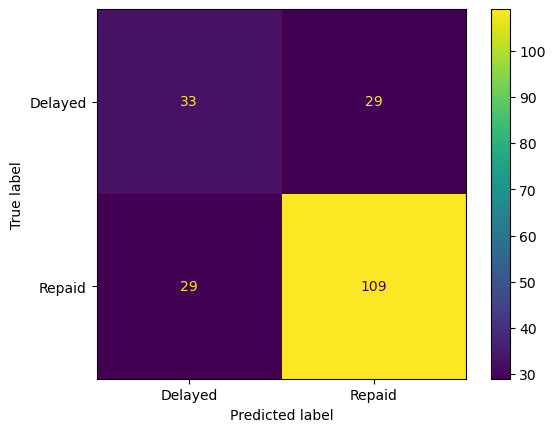

In [153]:
ConfusionMatrixDisplay.from_predictions(y_test,y_predict)
plt.show()

In [154]:
y_test.value_counts()

default
Repaid     138
Delayed     62
Name: count, dtype: int64

In [155]:
credit.existing_credits.value_counts()

existing_credits
1    633
2    333
3     28
4      6
Name: count, dtype: int64

In [156]:
model.get_depth(),model.get_n_leaves(),model.feature_names_in_,model.classes_

(9,
 np.int64(20),
 array(['amount', 'months_loan_duration', 'existing_credits',
        'checking_balance', 'savings_balance'], dtype=object),
 array(['Delayed', 'Repaid'], dtype=object))

In [157]:
model.feature_importances_

array([0.3641943 , 0.15326118, 0.02391086, 0.41645552, 0.04217814])